# 미션 16 — 모델 추출 (`modeling.ipynb`)

**주제:** 이전 미션에서 다룬 모델(CNN)을 MNIST로 학습한 뒤, 3가지 포맷으로 변환·저장한다.

| 산출물 | 파일명 | 설명 |
|---|---|---|
| PyTorch 기본 | `mission_16_simplecnn_fp32.pth` | `state_dict` 저장 (FP32) |
| PyTorch 양자화 | `mission_16_simplecnn_int8.pth` | Static PTQ(INT8) → TorchScript 저장 |
| ONNX | `mission_16_simplecnn.onnx` | `torch.onnx.export` (opset 17, dynamic_axes) |

> 학습 자료 매핑 — ONNX 변환(Ch.2), 양자화/PTQ(Ch.4), 저장·용량 비교(Ch.4.5)

---

## 0. 라이브러리 설치

In [9]:
!pip install onnx onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 68.7 MB/s eta 0:00:00


In [1]:
import os, copy, warnings
import numpy as np, torch, torch.nn as nn
import torch.ao.quantization as tq

warnings.filterwarnings("ignore")
torch.manual_seed(42); np.random.seed(42)
torch.backends.quantized.engine = "fbgemm"   # x86 CPU용 양자화 백엔드
print("torch", torch.__version__)

torch 2.11.0+cu128


## Google Drive 마운트 (선택)
Colab 환경에서 데이터 파일을 Drive에서 불러올 경우 사용.

In [13]:
# Colab에서 Google Drive 마운트 (옵션)
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    IS_COLAB = True
except ImportError:
    IS_COLAB = False
    print("로컬 환경에서 실행 중입니다.")

Mounted at /content/drive


In [14]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 드라이브 마운트 작업 후 아래 경로에서 폰트 가져오기
# /content/drive/MyDrive/fonts/NanumGothic.ttf

font_path = f'/content/drive/MyDrive/fonts/NanumGothic.ttf'  # 설치한 폰트 경로
fm.fontManager.addfont(font_path)  # 폰트 경로 추가

plt.rcParams['font.family'] = 'NanumGothic'  # 사용 폰트 입력
plt.rcParams['axes.unicode_minus'] = False   # 음수 부호 사용

## 1. 데이터 준비 (MNIST)
공개 벤치마크 MNIST를 평가 데이터셋으로 사용합니다.

In [2]:
# MNIST 로더: torchvision 기본 미러가 막힌 환경에서도 동작하도록 fallback 포함
import os, gzip, pickle, urllib.request
import numpy as np, torch
from torch.utils.data import TensorDataset, DataLoader

MNIST_MEAN, MNIST_STD = 0.1307, 0.3081

def _load_from_pkl_mirror():
    url = "https://raw.githubusercontent.com/mnielsen/neural-networks-and-deep-learning/master/data/mnist.pkl.gz"
    path = "mnist.pkl.gz"
    if not os.path.exists(path):
        urllib.request.urlretrieve(url, path)
    with gzip.open(path, "rb") as f:
        tr, va, te = pickle.load(f, encoding="latin1")
    def pack(X, y):
        X = ((X.reshape(-1,1,28,28).astype("float32")) - MNIST_MEAN) / MNIST_STD
        return torch.from_numpy(X), torch.from_numpy(y.astype("int64"))
    Xtr, ytr = pack(np.concatenate([tr[0],va[0]]), np.concatenate([tr[1],va[1]]))
    Xte, yte = pack(te[0], te[1])
    return TensorDataset(Xtr,ytr), TensorDataset(Xte,yte)

def get_mnist_loaders(batch_size=128, test_batch=256):
    """가능하면 torchvision.datasets.MNIST 사용, 실패 시 github 미러로 fallback."""
    try:
        import torchvision, torchvision.transforms as T
        tf = T.Compose([T.ToTensor(), T.Normalize((MNIST_MEAN,), (MNIST_STD,))])
        train_ds = torchvision.datasets.MNIST("./data", train=True,  download=True, transform=tf)
        test_ds  = torchvision.datasets.MNIST("./data", train=False, download=True, transform=tf)
        print("데이터 출처: torchvision.datasets.MNIST")
    except Exception as e:
        print("torchvision MNIST 다운로드 실패 → github 미러 fallback:", type(e).__name__)
        train_ds, test_ds = _load_from_pkl_mirror()
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=test_batch, shuffle=False)
    return train_loader, test_loader

In [3]:
train_loader, test_loader = get_mnist_loaders()
xb, yb = next(iter(train_loader))
print("배치 shape:", xb.shape, "| 학습 배치 수:", len(train_loader))

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 489kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.53MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.37MB/s]

데이터 출처: torchvision.datasets.MNIST
배치 shape: torch.Size([128, 1, 28, 28]) | 학습 배치 수: 469


## 2. 모델 정의
양자화(Static PTQ)를 염두에 두고 `QuantStub`/`DeQuantStub`를 포함한 소형 CNN을 정의합니다.

In [4]:
import torch.nn as nn
import torch.ao.quantization as tq

class SimpleCNN(nn.Module):
    """MNIST용 소형 CNN. Static PTQ 양자화를 위해 QuantStub/DeQuantStub 포함.
       (Conv+ReLU를 모듈로 분리해두면 fuse_modules로 융합 가능)"""
    def __init__(self):
        super().__init__()
        self.quant = tq.QuantStub()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1); self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1); self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)
        self.fc    = nn.Linear(32*7*7, 10)
        self.dequant = tq.DeQuantStub()
    def forward(self, x):
        x = self.quant(x)
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = torch.flatten(x, 1)   # 주의: .view() 대신 flatten (양자화 텐서 호환)
        x = self.fc(x)
        return self.dequant(x)

## 3. FP32 모델 학습
직접 학습(3 epoch)합니다. `model.eval()`은 평가/변환 직전에 호출합니다(BatchNorm·Dropout 동작 고정 — Ch.2).

In [5]:
def evaluate(model, loader):
    model.eval(); correct = total = 0
    with torch.no_grad():
        for xb, yb in loader:
            correct += (model(xb).argmax(1) == yb).sum().item(); total += yb.size(0)
    return correct / total * 100

model = SimpleCNN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

for epoch in range(3):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward(); optimizer.step()
    print(f"[FP32] epoch {epoch+1}/3  test_acc = {evaluate(model, test_loader):.2f}%")

acc_fp32 = evaluate(model, test_loader)
print("FP32 최종 정확도:", round(acc_fp32, 2), "%")

[FP32] epoch 1/3  test_acc = 97.94%
[FP32] epoch 2/3  test_acc = 98.50%
[FP32] epoch 3/3  test_acc = 98.33%
FP32 최종 정확도: 98.33 %


## 4. 모델 3종 변환·저장

### 4-1. PyTorch 기본 (`.pth`, state_dict)
일반 모델은 `state_dict`(가중치만) 저장이 권장됩니다 — 작고 안전 (Ch.4.5).

In [6]:
os.makedirs("outputs", exist_ok=True)
torch.save(model.state_dict(), "outputs/mission_16_simplecnn_fp32.pth")
print("저장 완료: mission_16_simplecnn_fp32.pth")

저장 완료: mission_16_simplecnn_fp32.pth


### 4-2. 양자화 (`.pth`, Static PTQ → INT8)
학습이 끝난 FP32 모델을 재훈련 없이 INT8로 변환합니다(PTQ, Ch.4).
1. `fuse_modules`로 Conv+ReLU 융합 → 2. `qconfig` 설정 → 3. `prepare` → 4. 캘리브레이션 → 5. `convert`

> **⚠️ 디버깅 노트 (실제 겪은 오류)**
> - `x.view(...)` 사용 시 양자화 텐서에서 `view size is not compatible ...` 오류 → `torch.flatten(x,1)`로 해결 (모델 정의에 이미 반영).
> - 양자화 모델을 `torch.save(model, ...)`(객체 전체)로 저장 후 다시 `torch.load` 하면 `'ConvReLU2d' object has no attribute '_backward_hooks'` 오류 발생(torch 2.x pickle 이슈). → **양자화 모델은 `torch.jit.script` + `torch.jit.save`(TorchScript)로 저장**하는 것이 견고하며 배포에도 권장됩니다.

In [7]:
# 1) 융합 → 2) qconfig → 3) prepare
q_model = copy.deepcopy(model).eval()
q_model = tq.fuse_modules(q_model, [["conv1", "relu1"], ["conv2", "relu2"]])
q_model.qconfig = tq.get_default_qconfig("fbgemm")
tq.prepare(q_model, inplace=True)

# 4) 캘리브레이션 (수백 샘플이면 충분)
with torch.no_grad():
    for i, (xb, _) in enumerate(train_loader):
        q_model(xb)
        if i >= 4: break

# 5) 변환(INT8)
tq.convert(q_model, inplace=True)
acc_int8 = evaluate(q_model, test_loader)
print("INT8(Static PTQ) 정확도:", round(acc_int8, 2), "%  | 손실:",
      round(acc_fp32 - acc_int8, 2), "%p")

# TorchScript 로 저장 (양자화 모델 견고한 직렬화)
torch.jit.save(torch.jit.script(q_model), "outputs/mission_16_simplecnn_int8.pth")
print("저장 완료: mission_16_simplecnn_int8.pth")

INT8(Static PTQ) 정확도: 98.24 %  | 손실: 0.09 %p
저장 완료: mission_16_simplecnn_int8.pth


### 4-3. ONNX 변환 (`.onnx`)
`opset_version=17`과 `dynamic_axes`(배치 가변)를 명시합니다 (Ch.2). 변환 후 `onnx.checker`와 수치 동등성(PyTorch vs ONNX, `max_diff < 1e-5`)을 검증합니다.

In [10]:
import onnx, onnxruntime as ort

model.eval()
dummy = torch.randn(1, 1, 28, 28)
export_kwargs = dict(
    input_names=["input"], output_names=["output"],
    opset_version=17, do_constant_folding=True,
    dynamic_axes={"input": {0: "batch"}, "output": {0: "batch"}},
)
try:
    torch.onnx.export(model, dummy, "outputs/mission_16_simplecnn.onnx", dynamo=False, **export_kwargs)
except TypeError:   # 구버전 torch는 dynamo 인자 없음
    torch.onnx.export(model, dummy, "outputs/mission_16_simplecnn.onnx", **export_kwargs)

m = onnx.load("outputs/mission_16_simplecnn.onnx")
onnx.checker.check_model(m)
sess = ort.InferenceSession("outputs/mission_16_simplecnn.onnx", providers=["CPUExecutionProvider"])
with torch.no_grad(): pt_out = model(dummy).numpy()
onnx_out = sess.run(None, {"input": dummy.numpy()})[0]
print("opset:", m.opset_import[0].version, "| nodes:", len(m.graph.node))
print("수치 동등성 max_diff:", f"{np.abs(pt_out - onnx_out).max():.2e}", "(1e-5 이하면 정상)")

opset: 17 | nodes: 8
수치 동등성 max_diff: 1.07e-06 (1e-5 이하면 정상)


## 5. 변환된 모델 용량 비교 + 캡쳐 이미지 저장
제출용 "모델·용량 한눈에 보기" 이미지를 생성합니다.

In [11]:
import pandas as pd
files = [("PyTorch FP32 (기본)", "mission_16_simplecnn_fp32.pth", acc_fp32),
         ("PyTorch INT8 (양자화)", "mission_16_simplecnn_int8.pth", acc_int8),
         ("ONNX (FP32)",          "mission_16_simplecnn.onnx",     acc_fp32)]
base = os.path.getsize("outputs/" + files[0][1]) / 1024
rows = []
for label, fn, ac in files:
    kb = os.path.getsize("outputs/" + fn) / 1024
    red = "-" if fn == files[0][1] else f"{(1 - kb/base)*100:.1f}%"
    rows.append({"모델": label, "파일명": fn, "용량(KB)": round(kb,1),
                 "감소율": red, "정확도(%)": round(ac,2)})
df = pd.DataFrame(rows); print(df.to_string(index=False)); df

                모델                           파일명  용량(KB)   감소율  정확도(%)
 PyTorch FP32 (기본) mission_16_simplecnn_fp32.pth    83.4     -   98.33
PyTorch INT8 (양자화) mission_16_simplecnn_int8.pth    42.4 49.2%   98.24
       ONNX (FP32)     mission_16_simplecnn.onnx    81.3  2.5%   98.33


,모델,파일명,용량(KB),감소율,정확도(%)
0,PyTorch FP32 (기본),mission_16_simplecnn_fp32.pth,83.4,-,98.33
1,PyTorch INT8 (양자화),mission_16_simplecnn_int8.pth,42.4,49.2%,98.24
2,ONNX (FP32),mission_16_simplecnn.onnx,81.3,2.5%,98.33


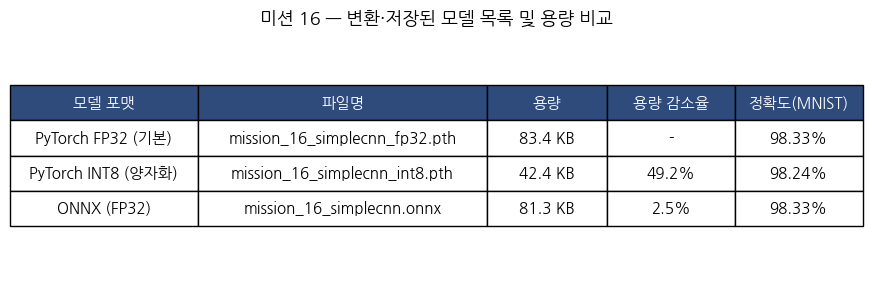

이미지 저장: outputs/model_size_comparison.png


In [15]:
import matplotlib; import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
# 한글 폰트(있으면 사용)
for fp in ["/usr/share/fonts/truetype/nanum/NanumGothic.ttf"]:
    if os.path.exists(fp):
        fm.fontManager.addfont(fp); plt.rcParams["font.family"] = fm.FontProperties(fname=fp).get_name()
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(11, 3)); ax.axis("off")
cell = [[r["모델"], r["파일명"], f'{r["용량(KB)"]:,.1f} KB', r["감소율"], f'{r["정확도(%)"]:.2f}%'] for r in rows]
cols = ["모델 포맷", "파일명", "용량", "용량 감소율", "정확도(MNIST)"]
tb = ax.table(cellText=cell, colLabels=cols, cellLoc="center", loc="center",
              colWidths=[0.22,0.34,0.14,0.15,0.15])
tb.auto_set_font_size(False); tb.set_fontsize(11); tb.scale(1, 2.1)
for j in range(len(cols)):
    tb[0,j].set_facecolor("#2f4b7c"); tb[0,j].set_text_props(color="white", fontweight="bold")
plt.title("미션 16 — 변환·저장된 모델 목록 및 용량 비교", fontsize=13, fontweight="bold", pad=12)
plt.savefig("outputs/model_size_comparison.png", dpi=170, bbox_inches="tight", facecolor="white")
plt.show(); print("이미지 저장: outputs/model_size_comparison.png")

## 정리
- **3종 포맷** 저장 완료: FP32(.pth) · INT8(.pth, TorchScript) · ONNX(.onnx)
- INT8 양자화로 용량 감소, 정확도 손실은 0.1%p 내외로 미미
- ONNX는 수치 동등성 검증 통과(`max_diff < 1e-5`)

→ 추론/검증은 `inference.ipynb`에서 진행합니다.